In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv('mahasiswa_lulus.csv')
df.head()

,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Lulus_Tepat_Waktu
0,3.22,91.1,9.4,Aktif,Menengah,Perempuan,Ya,Ya
1,2.94,100.0,9.1,Tidak Aktif,Rendah,Perempuan,Tidak,Ya
2,3.29,63.2,5.4,Tidak Aktif,Menengah,Perempuan,Tidak,Tidak
3,3.69,86.8,3.1,Aktif,Rendah,Laki-laki,Tidak,Ya
4,2.89,72.2,8.2,Aktif,Menengah,Laki-laki,Tidak,Ya


## 1. Preprocessing
### 1a. Handle Missing Value

In [2]:
num_cols = ['IPK', 'Kehadiran', 'Jam_Belajar']
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

cat_cols_with_na = ['Organisasi']
for col in cat_cols_with_na:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

df.isna().sum().sum()

np.int64(0)

### 1b. Encoding Fitur Kategorikal

In [3]:
categorical_features = ['Organisasi', 'Penghasilan_Ortu', 'Jenis_Kelamin', 'Status_Beasiswa']
label_encoders = {}

df_encoded = df.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

target_le = LabelEncoder()
df_encoded['Lulus_Tepat_Waktu'] = target_le.fit_transform(df_encoded['Lulus_Tepat_Waktu'])

### 1c. Train-Test Split 80:20

In [4]:
feature_cols = ['IPK', 'Kehadiran', 'Jam_Belajar', 'Organisasi',
                 'Penghasilan_Ortu', 'Jenis_Kelamin', 'Status_Beasiswa']
X = df_encoded[feature_cols]
y = df_encoded['Lulus_Tepat_Waktu']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((400, 7), (100, 7))

## 2. Modeling

In [5]:
dt3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt3.fit(X_train, y_train)
y_pred_dt3 = dt3.predict(X_test)

dt_full = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
dt_full.fit(X_train, y_train)
y_pred_dtfull = dt_full.predict(X_test)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

models = {
    'Decision Tree (depth=3)': (dt3, y_pred_dt3),
    'Decision Tree (depth=None)': (dt_full, y_pred_dtfull),
    'Gaussian Naive Bayes': (gnb, y_pred_gnb),
}

## 3. Evaluasi
### 3a. Akurasi, Precision, Recall, F1-Score

In [6]:
results = []
for name, (model, y_pred) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Akurasi': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1})

results_df = pd.DataFrame(results)
results_df

,Model,Akurasi,Precision,Recall,F1-Score
0,Decision Tree (depth=3),0.65,0.671053,0.836066,0.744526
1,Decision Tree (depth=None),0.65,0.703125,0.737705,0.720000
2,Gaussian Naive Bayes,0.76,0.753425,0.901639,0.820896


### 3b. Confusion Matrix

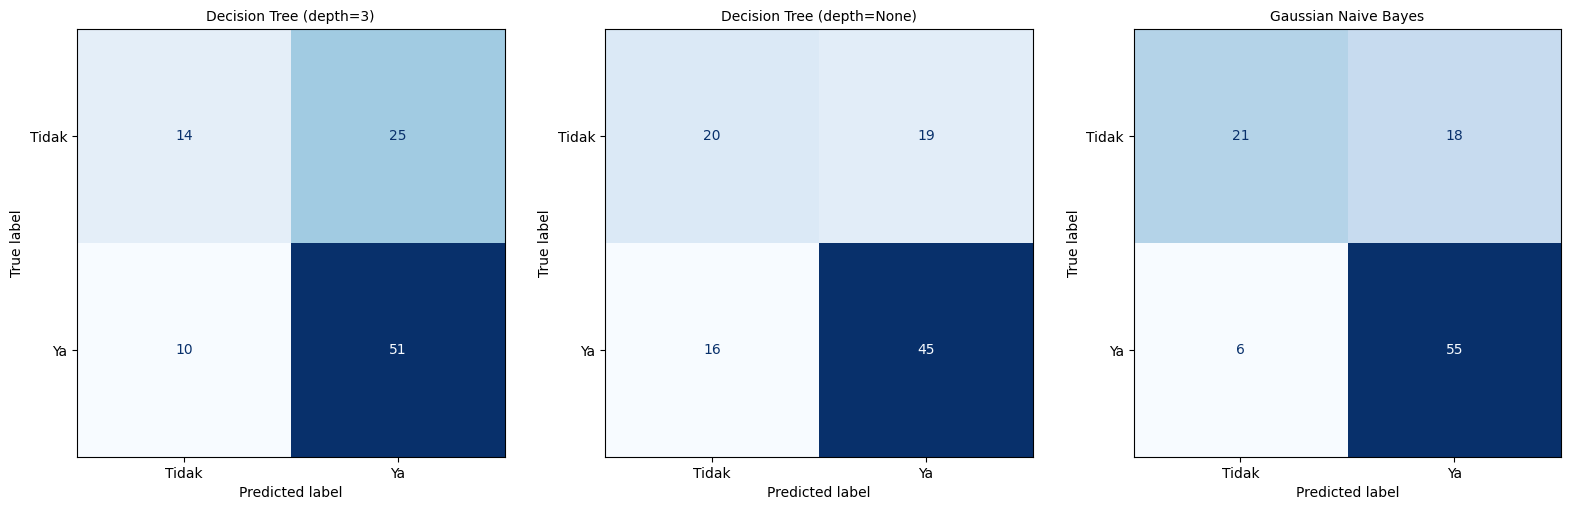

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, (model, y_pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Visualisasi
### 4a. Plot Pohon Keputusan (max_depth=3)

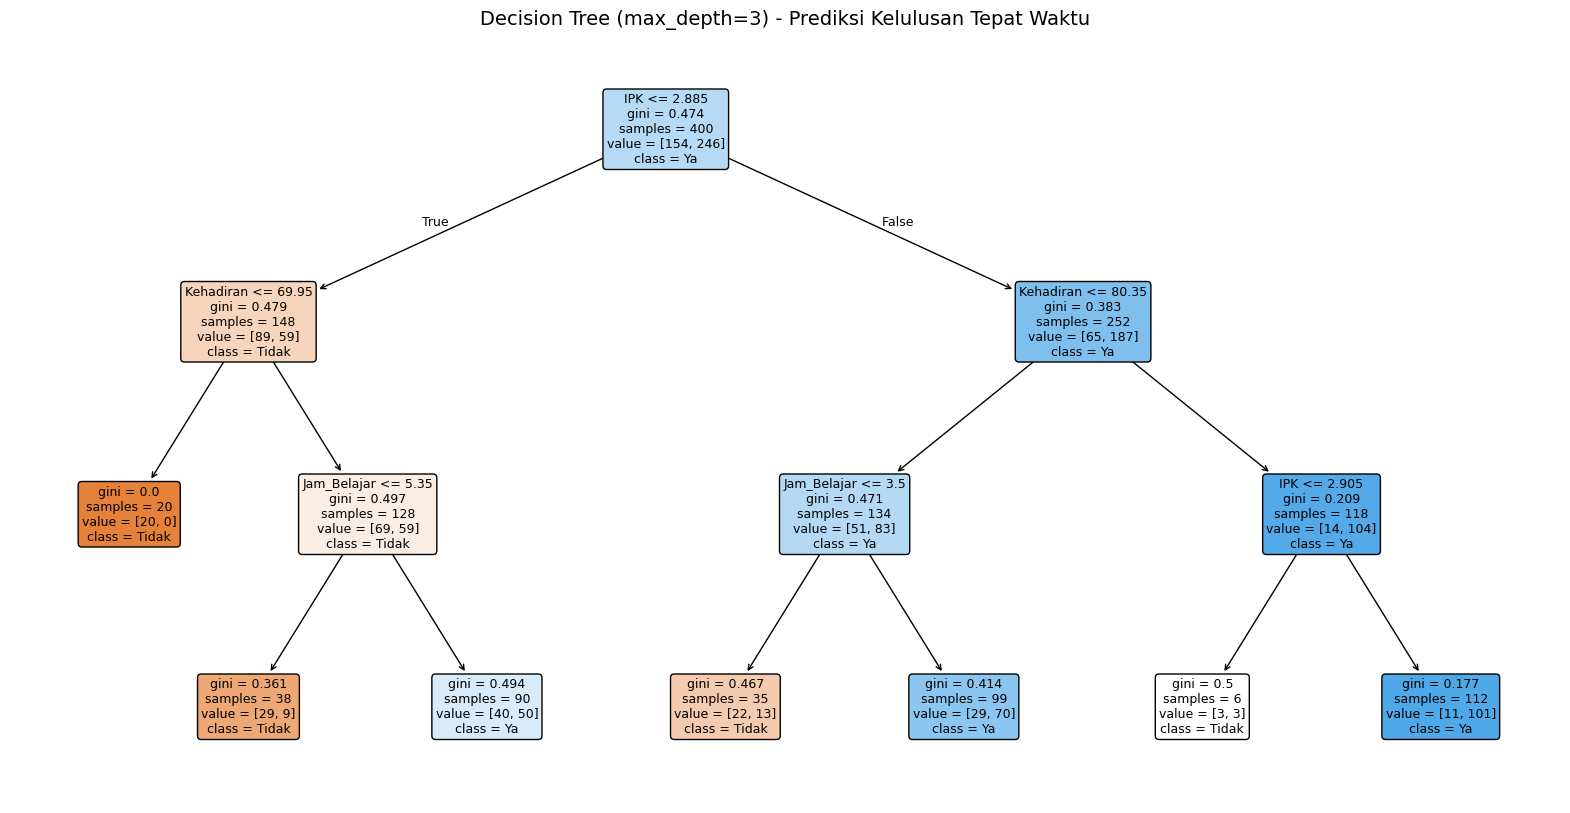

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(dt3, feature_names=feature_cols, class_names=target_le.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth=3) - Prediksi Kelulusan Tepat Waktu", fontsize=14)
plt.savefig('decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b. Perbandingan Metrik 3 Model (Bar Chart)

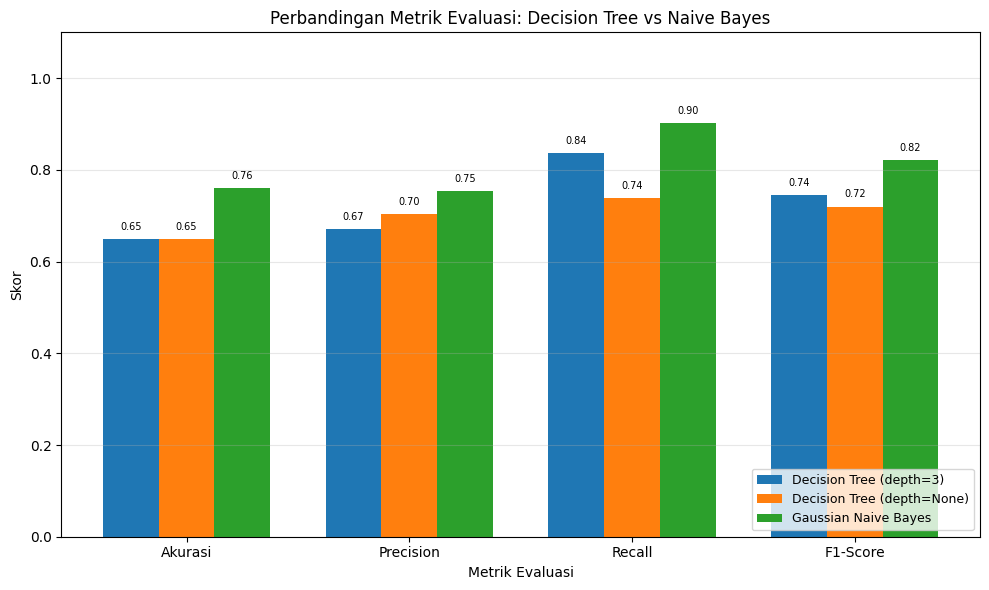

In [9]:
metrics = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, _) in enumerate(models.items()):
    values = results_df[results_df['Model'] == name][metrics].values.flatten()
    ax.bar(x + i * width, values, width, label=name)
    for j, v in enumerate(values):
        ax.text(x[j] + i * width, v + 0.02, f"{v:.2f}", ha='center', fontsize=7)

ax.set_xlabel('Metrik Evaluasi')
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Metrik Evaluasi: Decision Tree vs Naive Bayes')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analisis Error
Mengambil 5 contoh data yang salah diprediksi oleh model Decision Tree (max_depth=3).

In [10]:
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred_dt3, name='Prediksi')

error_df = X_test_reset.copy()
error_df['Aktual'] = target_le.inverse_transform(y_test_reset)
error_df['Prediksi'] = target_le.inverse_transform(y_pred_series)
error_df['IPK'] = error_df['IPK'].round(2)
error_df['Kehadiran'] = error_df['Kehadiran'].round(1)
error_df['Jam_Belajar'] = error_df['Jam_Belajar'].round(1)

misclassified = error_df[error_df['Aktual'] != error_df['Prediksi']]

sample_errors = misclassified.head(5)
sample_errors[['IPK', 'Kehadiran', 'Jam_Belajar', 'Organisasi', 'Aktual', 'Prediksi']]

,IPK,Kehadiran,Jam_Belajar,Organisasi,Aktual,Prediksi
4,2.89,57.3,6.0,0,Tidak,Ya
6,2.04,74.1,12.8,1,Tidak,Ya
8,2.63,98.6,4.6,1,Ya,Tidak
11,1.54,100.0,9.7,1,Tidak,Ya
12,2.44,87.3,9.0,0,Tidak,Ya
